# Grid-overview FOV finder — live demo

`GridFOVFinderAgent` is the density-aware alternative to `FOVFinderAgent`.
Instead of imaging scattered random candidates and returning those same points,
it:

1. images a small contiguous **grid** (e.g. 5×5) centred on each well,
2. segments every tile and reconstructs one global cloud of **cell centroids**,
3. places `fovs_per_well` FOV windows on the best clusters — *recentred onto
   the cells* and filtered by cell count + nearest-neighbour clumping.

Tune the density parameters offline first in
`grid_density_fov_finder_tuning.ipynb`, then drop the same numbers in here.

## 1. Microscope + channels

In [1]:
from faro.microscope.pertzlab.jungfrau import Jungfrau
from faro.core.data_structures import PowerChannel

mic = Jungfrau()
mic.mmc.setChannelGroup("TTL_ERK")
mic.mmc.setProperty("TIPFSStatus", "State", "On")  # PFS holds focus

imaging_channels = (
    PowerChannel(config="miRFP", exposure=125, group="TTL_ERK", power=95),
)

## 2. Segmentator

In [3]:
from faro.segmentation.cellpose_v4 import CellposeV4

segmentator = CellposeV4()

## 3. Configure and run the grid finder

Key knobs beyond the plate/well basics:

- `grid_rows` / `grid_cols` / `grid_overlap` — the overview-scan grid.
- `min_cells` / `max_cells` — accepted cell-count band per FOV.
- `clump_distance_um` / `max_clumped_fraction` — the *not-clumped* rule.
- `min_nn_um` / `max_nn_um` — optional *not-too-dense / not-too-sparse* band on the median NN distance.
- `recenter` — mean-shift each chosen FOV onto its cluster (the "move onto the nice cells" behaviour).
- `flip_x` / `flip_y` — camera→stage axis flips; a ~180° plate rotation is `True, True`.
- `pixel_size_um` / `fov_size_um` — leave `None` to read them from the camera at run time.

In [3]:
from napari_micromanager import MainWindow
import napari

viewer = napari.Viewer()
mm_wdg = MainWindow(
    viewer, mmcore=mic.mmc
)  # widget to control Micro-Manager from napari
viewer.window.add_dock_widget(mm_wdg)  # dock Micro-Manager controls in napari

[GridFOVFinderAgent] Phase 0: 5x5 grid scan in 1 well(s): ['C7'] (fov=666x666 µm, px=0.650)
[GridFOVFinderAgent] well C7: 909 cells in scan, 353 passing window(s), selected 3.


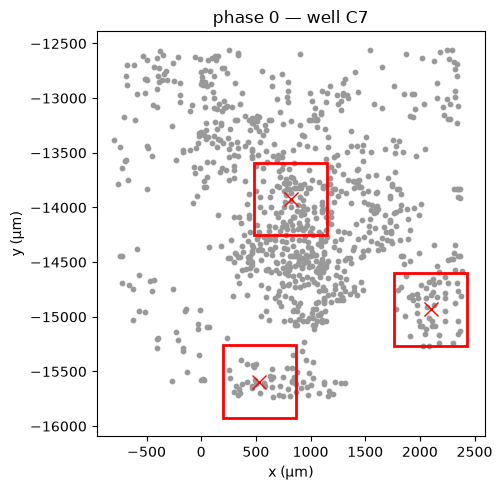

[GridFOVFinderAgent] Phase 0 — selected FOVs:
    C7_0000: 100 cells, clumped=0.05, med_nn=39.4µm
    C7_0001: 40 cells, clumped=0.05, med_nn=37.4µm
    C7_0002: 50 cells, clumped=0.00, med_nn=48.3µm


[FovPosition(x=819.1597843988955, y=-13922.769482009062, z=None, name='C7_0000'),
 FovPosition(x=530.0366330193935, y=-15593.405183299541, z=None, name='C7_0001'),
 FovPosition(x=2100.0384479262693, y=-14931.953478232448, z=None, name='C7_0002')]

In [20]:
from faro.agents import GridFOVFinderAgent

finder = GridFOVFinderAgent(
    microscope=mic,
    well_plate_plan="./calib_plate_96.json",
    wells=["C7"],
    fovs_per_well=3,
    grid_rows=5,
    grid_cols=5,
    grid_overlap=0.05,  # 5% tile overlap so there are no blind seams
    # --- density knobs (tune in grid_density_fov_finder_tuning.ipynb) ---
    min_cells=35,
    max_cells=100,
    clump_distance_um=15.0,
    max_clumped_fraction=0.2,
    recenter=True,
    imaging_channels=imaging_channels,
    segmentator=segmentator,
    seg_channel_index=0,
    z=None,  # PFS holds focus
    flip_x=False,
    flip_y=True,  # ~180° plate rotation on Jungfrau
    pixel_size_um=0.65,  # read mmc.getPixelSizeUm()
    fov_size_um=None,  # derive from pixel size * image dims
    random_seed=42,
    strict_count=True,  # always return fovs_per_well; tops up weak wells
    # with the best-scoring (densest) non-overlapping
    # leftover. Set False to instead return FEWER
    # FOVs for a well that lacks enough good fields.
    store_tiles=True,  # keep grid tiles so section 7 can stitch a
    # stage-coordinate montage to validate repositioning
    verbose=True,  # per-well scatter of cloud + chosen FOV boxes
)

positions = finder.run()
positions

## 4. Inspect the scan

`finder.last_run` holds the per-well centroid clouds and the full candidate-window DataFrames, so you can see *why* each FOV was chosen (or padded).

In [21]:
lr = finder.last_run
for well, df in lr["candidates_by_well"].items():
    n_pass = int(df["valid"].sum()) if len(df) else 0
    print(
        f"well {well}: {len(lr['clouds_by_well'][well])} cells, "
        f"{len(df)} candidate windows, {n_pass} passed the density filter"
    )

# full candidate table for the first well
first = next(iter(lr["candidates_by_well"]))
lr["candidates_by_well"][first][
    [
        "x",
        "y",
        "n_cells",
        "clumped_fraction",
        "median_nn_um",
        "density_per_mm2",
        "valid",
        "reason",
        "score",
    ]
].round(2)

well C7: 909 cells, 743 candidate windows, 353 passed the density filter


,x,y,n_cells,clumped_fraction,median_nn_um,density_per_mm2,valid,reason,score
0,-149.10,-15143.76,15,0.0,20.08,33.86,False,below_min_cells,15.0
1,-194.94,-15121.18,16,0.0,33.31,36.12,False,below_min_cells,16.0
2,-134.92,-15304.12,17,0.0,20.55,38.37,False,below_min_cells,17.0
3,-35.69,-15106.16,14,0.0,46.54,31.60,False,below_min_cells,14.0
4,278.28,-15423.23,29,0.0,33.73,65.46,False,below_min_cells,29.0
...,...,...,...,...,...,...,...,...,...
738,2189.62,-12974.30,24,0.0,51.88,54.17,False,below_min_cells,24.0
739,2168.35,-13016.93,22,0.0,55.38,49.66,False,below_min_cells,22.0
740,2175.79,-13036.27,21,0.0,59.12,47.40,False,below_min_cells,21.0
741,2119.19,-13056.20,22,0.0,62.70,49.66,False,below_min_cells,22.0


## 5. (Optional) hand the FOVs to an experiment

The returned `FovPosition` list plugs straight into the same downstream agents as `FOVFinderAgent` (e.g. `ComposedAgent` + `OscillationBO`), or pass `return_json=True` to get `useq.Position` objects for the MDA position list.

In [22]:
for fp in positions:
    print(f"{fp.name}: x={fp.x:.1f}  y={fp.y:.1f}  z={fp.z}")

C7_0000: x=819.2  y=-13922.8  z=None
C7_0001: x=530.0  y=-15593.4  z=None
C7_0002: x=2100.0  y=-14932.0  z=None


In [23]:
# Verify the handed FOVs are non-overlapping and well spread, per well.
import numpy as np

fov_w, fov_h = finder.last_run["fov_size_um"]
by_well = {}
for fp in positions:
    by_well.setdefault(fp.name.rsplit("_", 1)[0], []).append(fp)

for well, fps in by_well.items():
    pts = np.array([[fp.x, fp.y] for fp in fps])
    overlaps, dists = [], []
    for i in range(len(pts)):
        for j in range(i + 1, len(pts)):
            dx, dy = abs(pts[i, 0] - pts[j, 0]), abs(pts[i, 1] - pts[j, 1])
            overlaps.append(dx < fov_w and dy < fov_h)  # exact rectangle test
            dists.append(float(np.hypot(dx, dy)))
    ok = not any(overlaps)
    msg = f"min pairwise dist={min(dists):.0f} µm" if dists else "single FOV"
    print(f"well {well}: {len(fps)} FOVs, non-overlapping={ok}, {msg}")

well C7: 3 FOVs, non-overlapping=True, min pairwise dist=1631 µm


## 6. Acquire the selected FOVs and show them

Re-image each handed FOV position with the imaging channel and display
`raw | segmentation` (with the cell count) so you can eyeball what was picked
before committing them to an experiment. This drives the stage to every
selected position, so make sure the plate/PFS are ready.

Acquiring 3 selected FOV(s)...
  C7_0000: 97 cells  (x=819.2, y=-13922.8)
  C7_0001: 64 cells  (x=530.0, y=-15593.4)
  C7_0002: 56 cells  (x=2100.0, y=-14932.0)


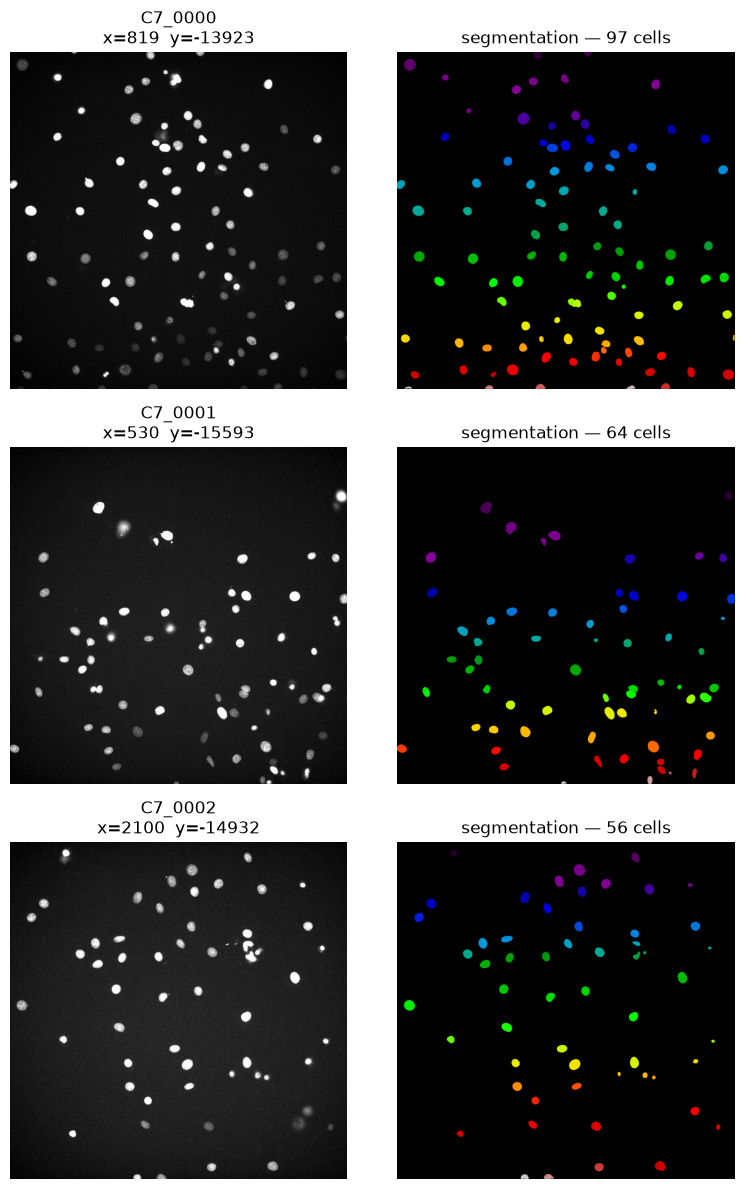

In [24]:
import matplotlib.pyplot as plt
import numpy as np

# Drive the stage to each selected FOV and acquire it (reuses the agent's
# own acquisition path, so channels/exposures match the scan).
print(f"Acquiring {len(positions)} selected FOV(s)...")
frames = finder._acquire_frames(positions)

seg_c = finder.seg_channel_index
n = len(positions)
fig, axes = plt.subplots(n, 2, figsize=(8, 4 * n), squeeze=False)
for p, fp in enumerate(positions):
    img = frames.get((p, seg_c))
    ax_raw, ax_seg = axes[p, 0], axes[p, 1]
    if img is None:
        ax_raw.set_title(f"{fp.name} — NO FRAME")
        ax_raw.axis("off")
        ax_seg.axis("off")
        print(f"  {fp.name}: missing frame")
        continue
    img = np.asarray(img)
    lab = segmentator.segment(img)
    n_cells = int(lab.max()) if lab.size else 0
    ax_raw.imshow(
        img, cmap="gray", vmin=np.percentile(img, 1), vmax=np.percentile(img, 99)
    )
    ax_raw.set_title(f"{fp.name}\nx={fp.x:.0f}  y={fp.y:.0f}")
    ax_raw.axis("off")
    ax_seg.imshow(lab, cmap="nipy_spectral")
    ax_seg.set_title(f"segmentation — {n_cells} cells")
    ax_seg.axis("off")
    print(f"  {fp.name}: {n_cells} cells  (x={fp.x:.1f}, y={fp.y:.1f})")
plt.tight_layout()
plt.show()

## 7. Validate the repositioning (does the overview match reality?)

If the freshly re-imaged FOVs don't look like the overview, the suspect is the
**pixel→stage transform** (`flip_x` / `flip_y` / axis mapping). This section
checks it two ways, using the grid tiles kept via `store_tiles=True`:

1. **Stitched montage.** We lay every tile of a well into one image *in stage
   coordinates* using the agent's exact transform, then overlay the detected
   cell centroids (cyan) and the selected FOV boxes (red). If the transform is
   right, the overlapping tile **seams line up seamlessly**, the cyan dots sit
   on real cells, and the red boxes land on clusters. If a flip is wrong, the
   seams tear / mirror and the dots fall off the cells.
2. **Expected vs actual.** For each selected FOV we crop that window out of the
   montage (what the finder *expects*) and show it next to the **fresh
   re-image** at the same stage position (flipped into the same orientation).
   They should show the same cells. A consistent mismatch ⇒ wrong flip; a small
   shift ⇒ stage repeatability / recentering, which is fine.

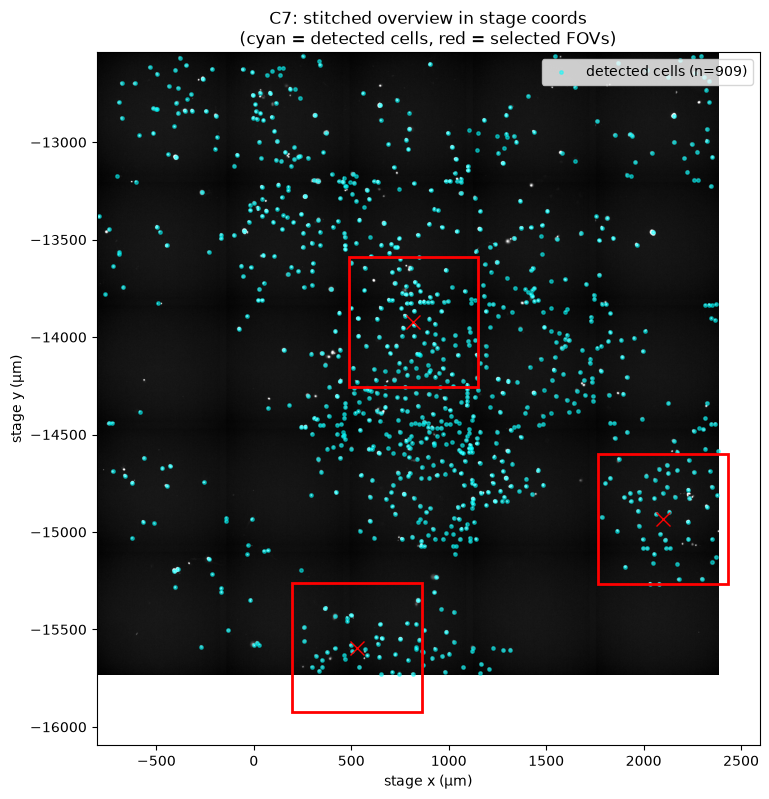

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from faro.agents.fov_density import build_stage_montage

WELL = "C7"  # which well to validate

lr = finder.last_run
assert lr.get("tile_images_by_well"), "Re-run the finder with store_tiles=True."
px = lr["pixel_size_um"]
fov_w, fov_h = lr["fov_size_um"]
fx, fy = lr["flip_x"], lr["flip_y"]

tiles = lr["tiles_by_well"][WELL]
imgs = lr["tile_images_by_well"][WELL]
keep = [(np.array([t.x, t.y]), im) for t, im in zip(tiles, imgs) if im is not None]
centers = np.array([c for c, _ in keep])
tile_imgs = [im for _, im in keep]

montage, (x0, x1, y0, y1) = build_stage_montage(
    centers, tile_imgs, px, flip_x=fx, flip_y=fy
)

cloud = lr["clouds_by_well"][WELL]
sel = [fp for fp in positions if fp.name.startswith(WELL + "_")]

fig, ax = plt.subplots(figsize=(9, 9))
ax.imshow(
    montage,
    origin="lower",
    extent=(x0, x1, y0, y1),
    cmap="gray",
    vmin=np.percentile(montage, 1),
    vmax=np.percentile(montage, 99.5),
)
ax.scatter(
    cloud[:, 0],
    cloud[:, 1],
    s=6,
    c="cyan",
    alpha=0.5,
    label=f"detected cells (n={len(cloud)})",
)
for fp in sel:
    ax.add_patch(
        Rectangle(
            (fp.x - fov_w / 2, fp.y - fov_h / 2),
            fov_w,
            fov_h,
            fill=False,
            edgecolor="red",
            linewidth=2,
        )
    )
    ax.plot(fp.x, fp.y, "rx", markersize=10)
ax.set_xlabel("stage x (µm)")
ax.set_ylabel("stage y (µm)")
ax.set_title(
    f"{WELL}: stitched overview in stage coords\n"
    f"(cyan = detected cells, red = selected FOVs)"
)
ax.legend(loc="upper right")
plt.show()

Re-imaging 3 FOV(s) in C7 to compare against the overview...


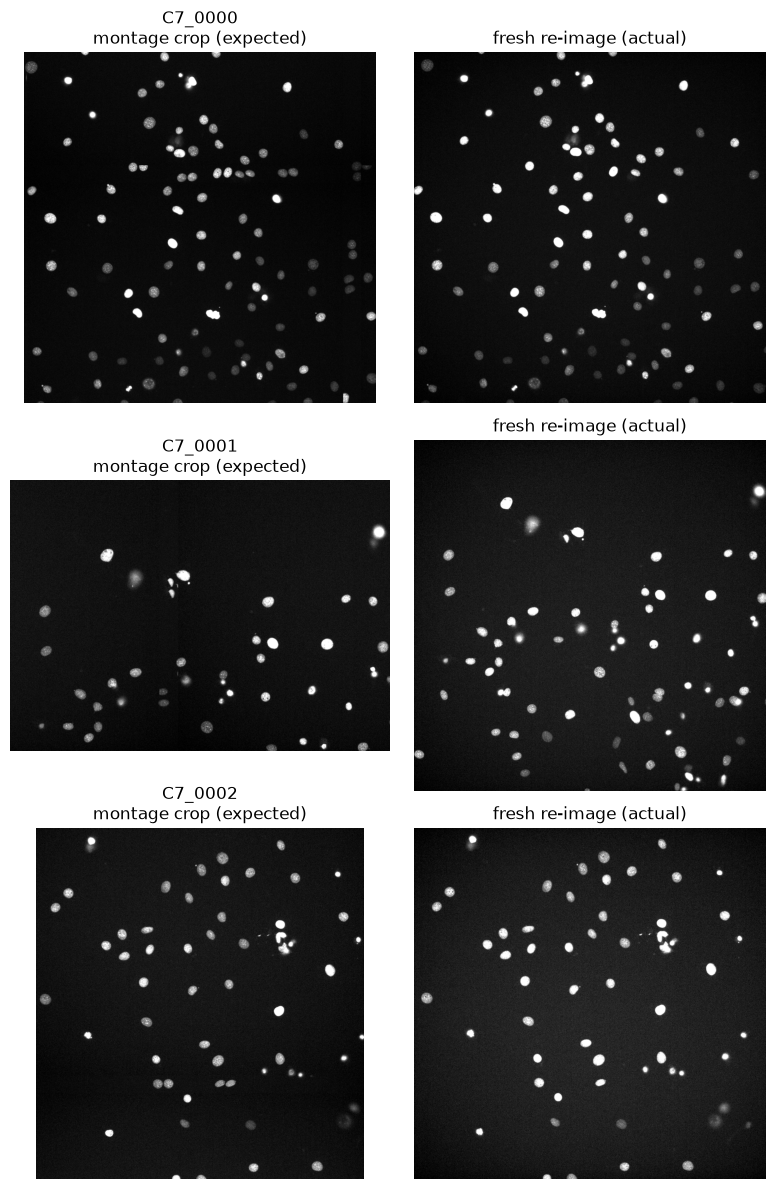

In [27]:
# Expected (montage crop) vs actual (fresh re-image) for each selected FOV.
print(f"Re-imaging {len(sel)} FOV(s) in {WELL} to compare against the overview...")
fresh = finder._acquire_frames(sel)
seg_c = finder.seg_channel_index

fig, axes = plt.subplots(len(sel), 2, figsize=(8, 4 * len(sel)), squeeze=False)
for i, fp in enumerate(sel):
    # crop the montage to this FOV window (stage coords -> montage pixels)
    c0 = int(round((fp.x - fov_w / 2 - x0) / px))
    c1 = int(round((fp.x + fov_w / 2 - x0) / px))
    r0 = int(round((fp.y - fov_h / 2 - y0) / px))
    r1 = int(round((fp.y + fov_h / 2 - y0) / px))
    crop = montage[max(r0, 0) : max(r1, 0), max(c0, 0) : max(c1, 0)]
    axes[i, 0].imshow(
        crop,
        origin="lower",
        cmap="gray",
        vmin=np.percentile(crop, 1) if crop.size else 0,
        vmax=np.percentile(crop, 99.5) if crop.size else 1,
    )
    axes[i, 0].set_title(f"{fp.name}\nmontage crop (expected)")

    img = fresh.get((i, seg_c))
    if img is not None:
        img = np.asarray(img, dtype=float)
        if fx:
            img = img[:, ::-1]
        if fy:
            img = img[::-1, :]
        axes[i, 1].imshow(
            img,
            origin="lower",
            cmap="gray",
            vmin=np.percentile(img, 1),
            vmax=np.percentile(img, 99),
        )
    axes[i, 1].set_title("fresh re-image (actual)")
    axes[i, 0].axis("off")
    axes[i, 1].axis("off")
plt.tight_layout()
plt.show()

## 8. Measure the pixel→stage mapping (don't guess `flip_x`/`flip_y`)

`flip_x` / `flip_y` describe how the **camera** is oriented relative to the
**stage** — pure hardware geometry, unrelated to the plate's 180° rotation
(that only moves the well centres, which `WellPlatePlan` already handles). So
we measure it instead of assuming.

The cell below: snaps a frame, moves the stage a known `+D` µm in **x**, snaps
again; then `+D` in **y**; and cross-correlates to see *which pixel axis* the
content moved along and *which direction*. That fixes `flip_x` / `flip_y` and
reports the implied pixel size as a sanity check. It self-calibrates the
cross-correlation sign convention first (by shifting a frame a known amount),
so the recommendation is unambiguous.

If the content moves along the **unexpected** axis (stage-x → image *rows*),
the camera is rotated ~90° and flips alone can't fix it — tell me and I'll add
a rotation/axis-swap option to the transform.

Run it somewhere with cells in view and room to move the stage ±D µm.

In [28]:
import numpy as np
from scipy.ndimage import shift as nd_shift
from skimage.registration import phase_cross_correlation
from faro.core.utils import FovPosition

mmc = mic.mmc
seg_c = finder.seg_channel_index
px = finder.pixel_size_um or float(mmc.getPixelSizeUm())
D = 150.0  # µm test move (keep < ~25% of the FOV so features stay in frame)


def _snap_at(x, y):
    fr = finder._acquire_frames([FovPosition(x=x, y=y, z=None, name="cal")])
    return np.asarray(fr[(0, seg_c)], dtype=float)


x0, y0 = float(mmc.getXPosition()), float(mmc.getYPosition())
print(f"calibrating at stage ({x0:.0f}, {y0:.0f}) with D={D} µm, px={px} ...")
I0 = _snap_at(x0, y0)
Ix = _snap_at(x0 + D, y0)
Iy = _snap_at(x0, y0 + D)
mmc.setXYPosition(x0, y0)  # return home

# --- self-calibrate phase_cross_correlation's sign convention ----------
# Shift I0 by a KNOWN displacement, recover it, and learn the sign k such that
#   true_feature_displacement = k * phase_cross_correlation(I0, moved).
# (skimage returns -displacement, so k should come out -1.)
known = np.array([20.0, 0.0])  # (row, col) we shift I0 content by
test = nd_shift(I0, shift=known, mode="nearest")
s_test, _, _ = phase_cross_correlation(I0, test, upsample_factor=20)
if abs(s_test[0]) < 5:
    print(
        f"⚠ weak self-calibration (pcc={np.round(s_test,2)} for a {known} shift) "
        "— run where the frame has clear features/cells or results may be unreliable."
    )
k = float(np.sign(known[0] / s_test[0])) if s_test[0] != 0 else -1.0  # expected -1
print(f"sign calibration: applied {known} -> pcc {np.round(s_test,2)} -> k={k:+.0f}")


def _displacement(ref, moved):
    s, _, _ = phase_cross_correlation(ref, moved, upsample_factor=20)
    return k * np.asarray(s)  # (drow, dcol) the feature actually moved by


d_x = _displacement(I0, Ix)  # feature shift when stage moved +D in x
d_y = _displacement(I0, Iy)  # feature shift when stage moved +D in y
print(f"stage +x{D:+.0f}µm -> feature moved (drow,dcol)px = {np.round(d_x,1)}")
print(f"stage +y{D:+.0f}µm -> feature moved (drow,dcol)px = {np.round(d_y,1)}")

# --- interpret ----------------------------------------------------------
# Finder maps: stage_x = cx + sx*px*(col - W/2),  stage_y = cy + sy*px*(row - H/2)
# For a fixed feature, +D in stage gives dcol = -D/(sx*px)  =>  sx = -sign(dcol).
# So flip_x (sx<0) <=> dcol_x > 0;  flip_y (sy<0) <=> drow_y > 0.
drow_x, dcol_x = d_x
drow_y, dcol_y = d_y
swap = (abs(drow_x) > abs(dcol_x)) or (abs(dcol_y) > abs(drow_y))

print("\n--- result ---")
if swap:
    print(
        "⚠ Camera is rotated ~90° vs stage (stage-x moved image ROWS / "
        "stage-y moved COLUMNS). flip_x/flip_y alone cannot fix this — the "
        "transform needs an axis-swap/rotation. Tell me and I'll add it."
    )
    print(
        f"  stage+x -> (drow,dcol)={np.round(d_x,1)}, "
        f"stage+y -> (drow,dcol)={np.round(d_y,1)}"
    )
else:
    rec_flip_x = bool(dcol_x > 0)
    rec_flip_y = bool(drow_y > 0)
    px_x = D / abs(dcol_x) if dcol_x else float("nan")
    px_y = D / abs(drow_y) if drow_y else float("nan")
    print(
        f"  implied pixel size: x={px_x:.3f}  y={px_y:.3f} µm/px " f"(configured {px})"
    )
    print(f"  RECOMMENDED:  flip_x={rec_flip_x}, flip_y={rec_flip_y}")
    print(f"  CURRENT:      flip_x={finder.flip_x}, flip_y={finder.flip_y}")
    if (rec_flip_x, rec_flip_y) != (finder.flip_x, finder.flip_y):
        print("  -> update the config cell with these flips and re-run the finder.")
    else:
        print(
            "  -> flips already correct; mismatch is elsewhere (focus / "
            "stage backlash / segmentation)."
        )

calibrating at stage (2099, -14933) with D=150.0 µm, px=0.65 ...
sign calibration: applied [20.  0.] -> pcc [-20.   0.] -> k=-1
stage +x+150µm -> feature moved (drow,dcol)px = [  -7.  -231.6]
stage +y+150µm -> feature moved (drow,dcol)px = [230.6  -7. ]

--- result ---
  implied pixel size: x=0.648  y=0.650 µm/px (configured 0.65)
  RECOMMENDED:  flip_x=False, flip_y=True
  CURRENT:      flip_x=False, flip_y=True
  -> flips already correct; mismatch is elsewhere (focus / stage backlash / segmentation).
